
  BITCOIN (BTC) vs AEX INDEX (NETHERLANDS) — IMPACT ANALYSIS

  Detected files:
    AEX Index : ./AEX Historical Data.csv
    Bitcoin   : ./Bitcoin Historical Data_crypto.csv

  Data loaded: 87 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Mar 2026

      Date  BTC_Return  AEX_Return
2019-01-01     -0.0734      0.0671
2019-02-01      0.1104      0.0392
2019-03-01      0.0749      0.0147
2019-04-01      0.2970      0.0412
2019-05-01      0.6085     -0.0544
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
            Count    Mean     Std     Min     25%     50%     75%     Max
BTC_Return   87.0  0.0503  0.1894 -0.3732 -0.0714  0.0246  0.1376  0.6085
AEX_Return   87.0  0.0087  0.0427 -0.1037 -0.0191  0.0086  0.0388  0.1351

  Pearson Correlation (Bitcoin vs AEX): 0.3409


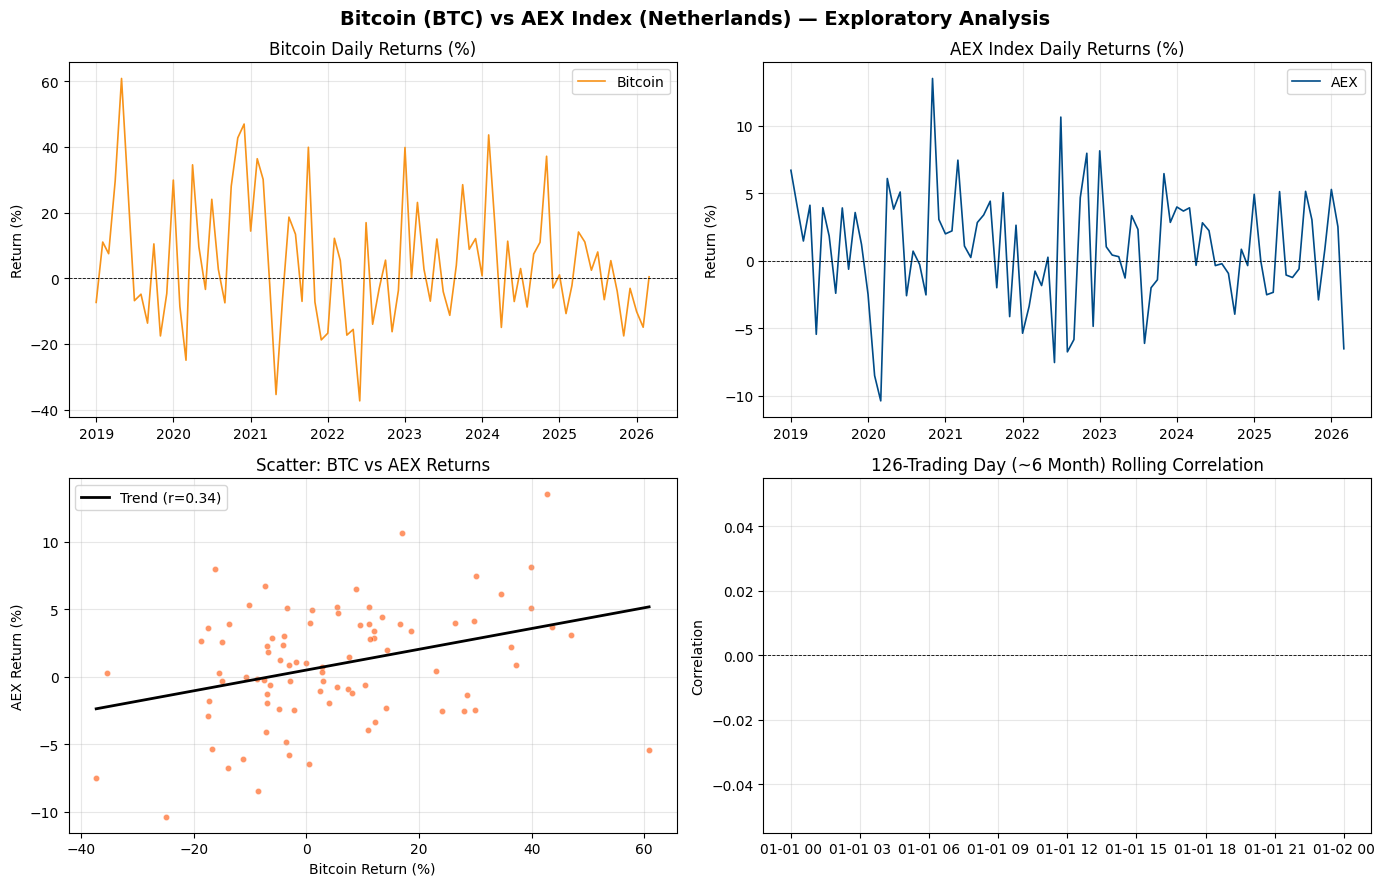


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average Bitcoin Return (X̄) = 5.0294%
    Average AEX Return     (Ȳ) = 0.8709%

  Step 4 — Slope β
    β = 0.0769
    → For every 1% rise in BTC, AEX changes by ~0.0769%

  Step 5 — Intercept α = 0.004842

  Step 6 — Regression Equation
    AEX_Return = 0.004842 + 0.0769 × BTC_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 0.0230
    t-statistic = 3.3429
    p-value     = 0.0012
    95% CI      = [0.0312, 0.1226]
    ✔ SIGNIFICANT — Reject H₀ (|t| = 3.34 > 2.0)

  Step 8 — Goodness of Fit
    R² = 0.1162  (11.62% of AEX variation explained by BTC)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             AEX_Return   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic

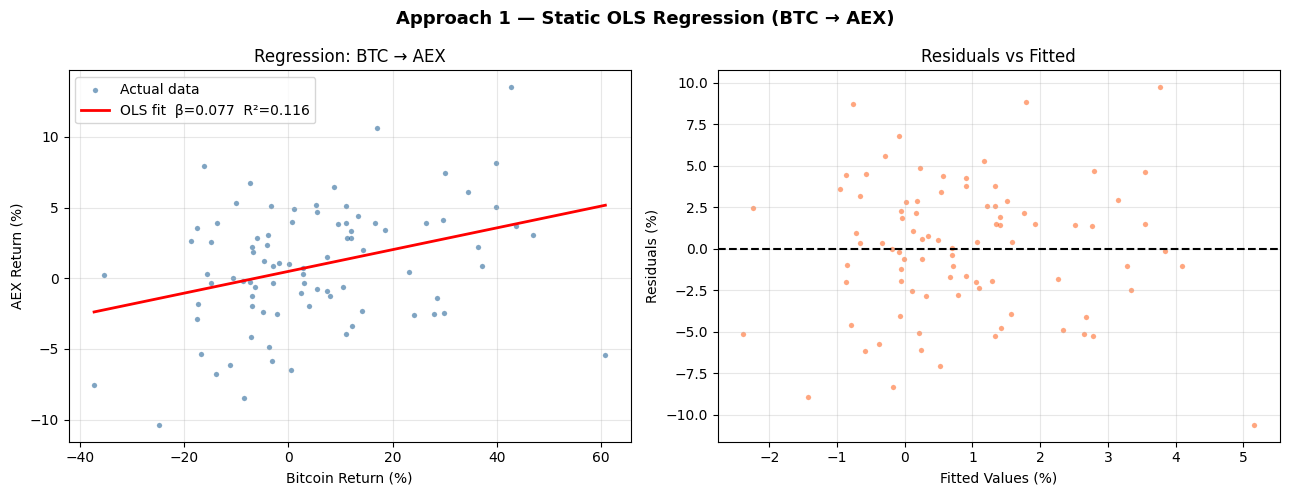


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    BTC Return                | ADF stat =  -7.390 | p = 0.0000 | ✔ Stationary
    AEX Return                | ADF stat =  -9.770 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of AEX Returns
    Lag-1 autocorrelation: -0.0701
    Lag-2 autocorrelation: -0.0431
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: AEX_t = α + β×BTC_t + γ×AEX_(t-1)

    Estimated equation:
    AEX_t = 0.00443 + 0.0790×BTC_t + -0.0510×AEX_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.0790  t=3.445  p=0.0009  ✔ Significant
    Lag effect   (γ): coef=-0.0510  t=-0.494  p=0.6225  ✘ Not significant

    R² (dynamic model) = 0.1294
    Adj. R²            = 0.1085

  Step 7 — Granger Causality Test
    H₀: BTC returns do NOT Granger-cause AEX returns
    Sample size: 87 obs → testing up to 

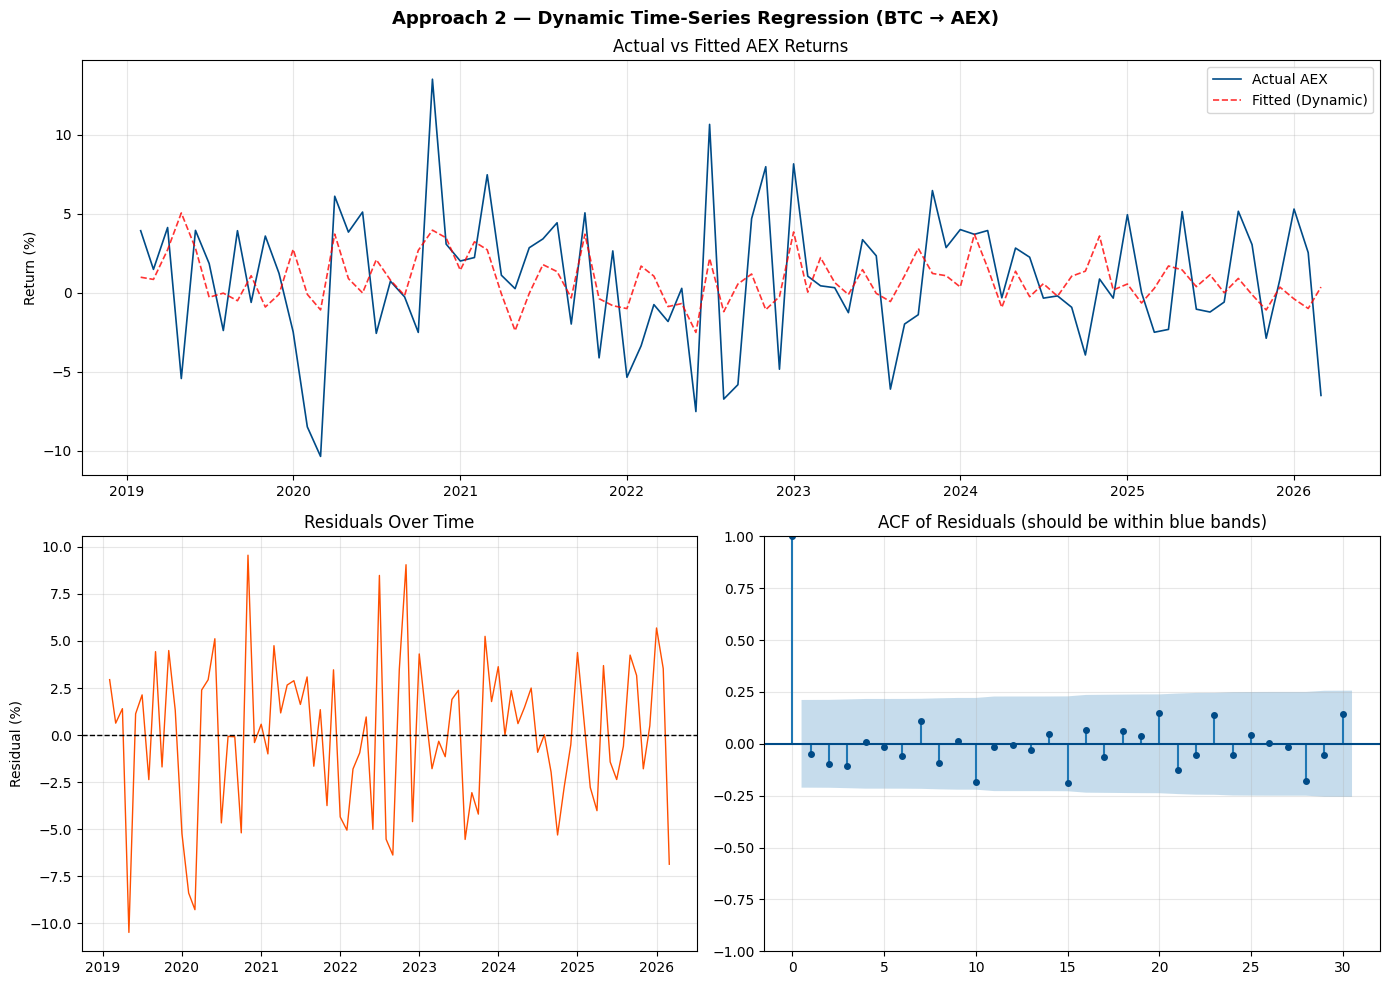


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.0769                    0.0790
Lag Term (γ)                Not included                   -0.0510
p-value (crypto)                  0.0012                    0.0009
R²                                0.1162                    0.1294
Accounts for Memory?                  No                       Yes


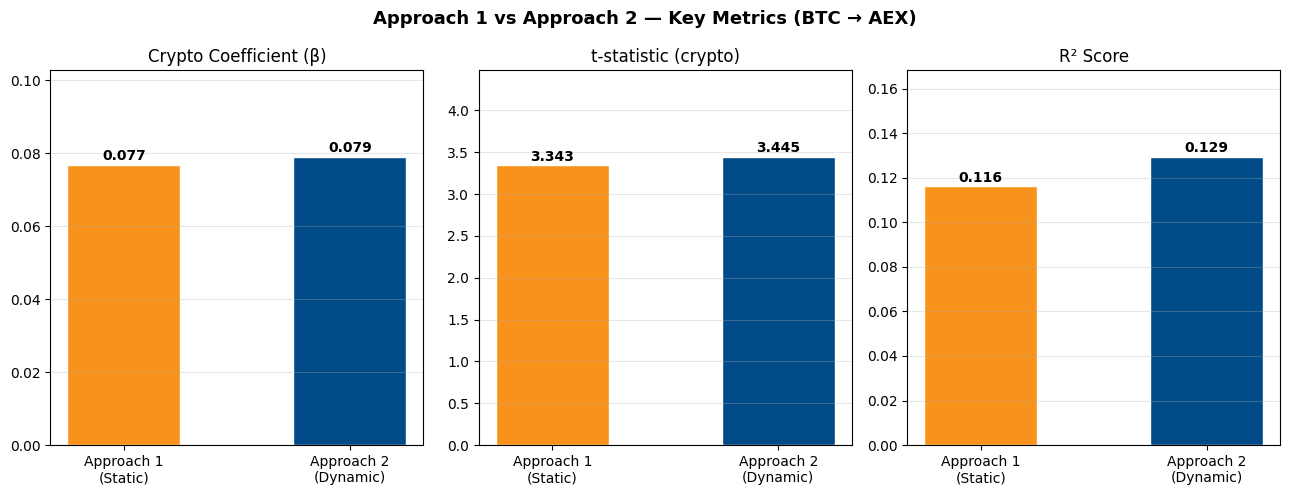


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Bitcoin (BTC) impact on AEX Index (Netherlands):

  ▸ Approach 1 (Static OLS):
      β = 0.0769 — a 1% BTC change correlates with ~0.077% AEX change
      R² = 0.1162
      Result: SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.0790 — immediate effect after controlling for momentum
      γ = -0.0510 — -5.1% of prior period's AEX return persists
      R² = 0.1294
      Result: SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR THE NETHERLANDS (AEX):
  1. The Market-Making Capital of Europe: Amsterdam is home to some of the world's 
     largest proprietary trading and high-frequency trading (HFT) firms, such as 
     Flow Traders and Optiver. Because these Dutch firms act as the primary 
     "Authorized Participants" and liquidity providers for European crypto ETPs, 
     the Dutch financial sector is heavily intertwined with crypto markets.
  2. Profiting from Volatility:

In [ ]:
# ============================================================
#   BITCOIN (BTC) vs AEX INDEX (NETHERLANDS) — IMPACT ANALYSIS
# ============================================================

import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])


import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# AUTO-DETECT UPLOADED CSV FILES
# ============================================================

search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both AEX and Bitcoin CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


AEX_FILE = next((f for f in csv_files if "AEX" in os.path.basename(f).upper() or "netherlands" in os.path.basename(f).lower()), None)
BTC_FILE = next((f for f in csv_files if "Bitcoin" in os.path.basename(f) or "bitcoin" in os.path.basename(f)
                                         or "crypto" in os.path.basename(f) or "BTC" in os.path.basename(f)), None)


if AEX_FILE is None or BTC_FILE is None:
    remaining = [f for f in csv_files if f not in (AEX_FILE, BTC_FILE)]
    if AEX_FILE is None and remaining:
        AEX_FILE = remaining.pop(0)
    if BTC_FILE is None and remaining:
        BTC_FILE = remaining.pop(0)

if AEX_FILE is None or BTC_FILE is None:
    raise FileNotFoundError(
        "Could not identify both AEX and Bitcoin CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'AEX' and 'Bitcoin'/'crypto'."
    )

print("\n" + "=" * 65)
print("  BITCOIN (BTC) vs AEX INDEX (NETHERLANDS) — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    AEX Index : {AEX_FILE}")
print(f"    Bitcoin   : {BTC_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()

    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)

    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

btc = load_and_clean(BTC_FILE, "BTC_Return")
aex = load_and_clean(AEX_FILE, "AEX_Return")


data = pd.merge(btc, aex, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "BTC_Return", "AEX_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["BTC_Return", "AEX_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["BTC_Return"].corr(data["AEX_Return"])
print(f"\n  Pearson Correlation (Bitcoin vs AEX): {corr:.4f}")

# Plot 1: Exploratory Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Bitcoin (BTC) vs AEX Index (Netherlands) — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["BTC_Return"] * 100, color="#F7931A", label="Bitcoin", linewidth=1.2) # Bitcoin Orange
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bitcoin Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["AEX_Return"] * 100, color="#004B87", label="AEX", linewidth=1.2) # Euronext Blue
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("AEX Index Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["BTC_Return"] * 100, data["AEX_Return"] * 100,
           alpha=0.6, color="#FF4F00", edgecolors="white", linewidth=0.4, s=20) # Dutch Orange
m, b = np.polyfit(data["BTC_Return"], data["AEX_Return"], 1)
x_line = np.linspace(data["BTC_Return"].min(), data["BTC_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="black", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("AEX Return (%)")
ax.set_title("Scatter: BTC vs AEX Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
roll_corr = data["BTC_Return"].rolling(126).corr(data["AEX_Return"])
ax.plot(data["Date"], roll_corr, color="#004B87", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["BTC_Return"]
Y = data["AEX_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average Bitcoin Return (X̄) = {x_mean*100:.4f}%")
print(f"    Average AEX Return     (Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in BTC, AEX changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    AEX_Return = {alpha:.6f} + {beta:.4f} × BTC_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse["BTC_Return"]
t_stat    = ols_model.tvalues["BTC_Return"]
p_value   = ols_model.pvalues["BTC_Return"]
ci        = ols_model.conf_int().loc["BTC_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")
print(f"    95% CI      = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of AEX variation explained by BTC)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (BTC → AEX)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#004B87", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("AEX Return (%)")
ax.set_title("Regression: BTC → AEX")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#FF4F00", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["BTC_Return"], "BTC Return"),
                     (data["AEX_Return"], "AEX Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of AEX Returns")
lag1_autocorr = data["AEX_Return"].autocorr(lag=1)
lag2_autocorr = data["AEX_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: AEX_t = α + β×BTC_t + γ×AEX_(t-1)")

data_dyn = data.copy()
data_dyn["AEX_Lag1"] = data_dyn["AEX_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["AEX_Return"]
X_dyn = sm.add_constant(data_dyn[["BTC_Return", "AEX_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["BTC_Return"]
gamma_dyn = dyn_model.params["AEX_Lag1"]

print(f"\n    Estimated equation:")
print(f"    AEX_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×BTC_t + {gamma_dyn:.4f}×AEX_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["BTC_Return", "AEX_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "BTC_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: BTC returns do NOT Granger-cause AEX returns")
granger_data = data[["AEX_Return", "BTC_Return"]].dropna()
max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
granger_maxlag    = min(5, max_allowable_lag)
print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (BTC → AEX)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#004B87", linewidth=1.2, label="Actual AEX")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted AEX Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#FF4F00", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#004B87", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_value:.4f}", f"{dyn_model.pvalues['BTC_Return']:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (BTC → AEX)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["BTC_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#F7931A", "#004B87"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if dyn_model.pvalues['BTC_Return'] < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Bitcoin (BTC) impact on AEX Index (Netherlands):

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% BTC change correlates with ~{beta:.3f}% AEX change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's AEX return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR THE NETHERLANDS (AEX):
  1. The Market-Making Capital of Europe: Amsterdam is home to some of the world's
     largest proprietary trading and high-frequency trading (HFT) firms, such as
     Flow Traders and Optiver. Because these Dutch firms act as the primary
     "Authorized Participants" and liquidity providers for European crypto ETPs,
     the Dutch financial sector is heavily intertwined with crypto markets.
  2. Profiting from Volatility: Unlike traditional companies that rely on physical
     sales, market makers profit from trading *volume* and *volatility*. When
     Bitcoin experiences massive price swings, these Amsterdam-based firms generate
     hundreds of millions in arbitrage revenue. This directly inflates their
     stock prices and pulls the broader index upwards.
  3. Shared Global Liquidity: The AEX is a highly developed, Euro-denominated
     index. A statistically significant relationship here does not indicate a
     currency crisis (like in emerging markets). Instead, it reflects a shared
     "Risk-On" environment. When global central banks inject liquidity, both European
     equities and digital assets experience synchronized inflows.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)